<a href="https://colab.research.google.com/github/JSEFERINO/Archivos-DOE-2026/blob/main/Fernel_Thomas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

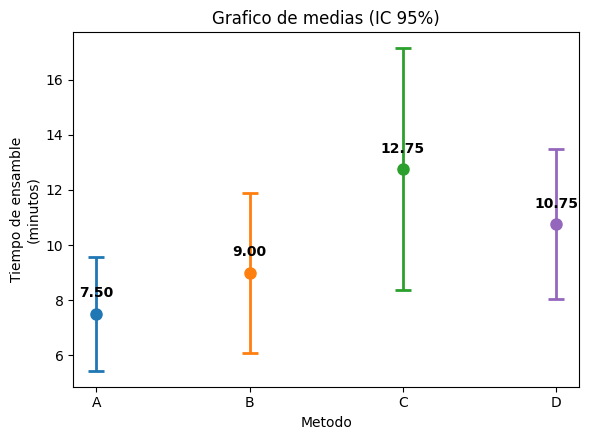

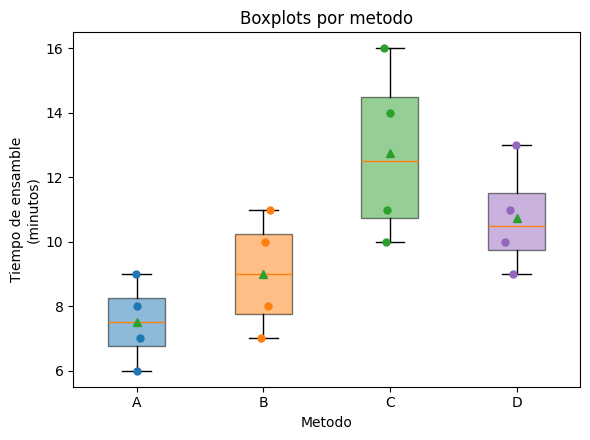

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# Datos: filas = operadores (bloques), columnas = métodos (tratamientos)
datos = {
    'A': [6, 9, 7, 8],
    'B': [7, 10, 11, 8],
    'C': [10, 16, 11, 14],
    'D': [10, 13, 11, 9],
}
Y = pd.DataFrame(datos, index=[1, 2, 3, 4])
Y.index.name = 'Operador'

k = Y.shape[1]      # métodos (tratamientos)
b = Y.shape[0]      # operadores (bloques)
N = k * b

Y_total = Y.values.sum()
FC = Y_total**2 / N

SST = (Y.values**2).sum() - FC

Y_i_punto = Y.sum(axis=0)                     # total por método
SS_metodos = (Y_i_punto**2).sum() / b - FC

Y_punto_j = Y.sum(axis=1)                     # total por operador
SS_bloques = (Y_punto_j**2).sum() / k - FC

SS_error = SST - SS_metodos - SS_bloques

gl_metodos = k - 1
gl_bloques = b - 1
gl_error   = (k - 1) * (b - 1)
gl_total   = N - 1

CM_metodos = SS_metodos / gl_metodos
CM_bloques = SS_bloques / gl_bloques
CM_error   = SS_error / gl_error

F0_metodos = CM_metodos / CM_error
F0_bloques = CM_bloques / CM_error

p_metodos = stats.f.sf(F0_metodos, gl_metodos, gl_error)
p_bloques = stats.f.sf(F0_bloques, gl_bloques, gl_error)

tabla_anova = pd.DataFrame({
    'SC':      [SS_metodos, SS_bloques, SS_error, SST],
    'gl':      [gl_metodos, gl_bloques, gl_error, gl_total],
    'CM':      [CM_metodos, CM_bloques, CM_error, np.nan],
    'F0':      [F0_metodos, F0_bloques, np.nan, np.nan],
    'valor-p': [p_metodos, p_bloques, np.nan, np.nan],
}, index=['Métodos', 'Bloques', 'Error', 'Total'])

tabla_anova.round(4)

# Tabla de promedios
resumen = pd.DataFrame({'Total': Y.sum(), 'Promedio': Y.mean()})
resumen.index.name = 'Metodo'
resumen.round(2)

# Gráfico de medias con IC 95%
import matplotlib.pyplot as plt

metodos = list(Y.columns)
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
medias = Y.mean()
desv = Y.std(ddof=1)
n_obs = Y.shape[0]
t_crit = stats.t.ppf(0.975, df=n_obs - 1)
margen = t_crit * desv / np.sqrt(n_obs)

fig, ax = plt.subplots(figsize=(6, 4.5))
for i, m in enumerate(metodos):
    ax.errorbar(i, medias[m], yerr=margen[m], fmt='o', color=colores[i],
                capsize=6, markersize=8, elinewidth=2, capthick=2)
    ax.annotate(f'{medias[m]:.2f}', (i, medias[m]), textcoords='offset points',
                xytext=(0, 12), ha='center', fontweight='bold')
ax.set_xticks(range(len(metodos))); ax.set_xticklabels(metodos)
ax.set_xlabel('Metodo'); ax.set_ylabel('Tiempo de ensamble\n(minutos)')
ax.set_title('Grafico de medias (IC 95%)')
plt.tight_layout(); plt.show()

# Boxplots por método
fig, ax = plt.subplots(figsize=(6, 4.5))
bp = ax.boxplot([Y[m] for m in metodos], tick_labels=metodos, patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color); patch.set_alpha(0.5)
rng = np.random.default_rng(0)
for i, m in enumerate(metodos):
    x_jitter = rng.normal(i + 1, 0.04, size=len(Y[m]))
    ax.scatter(x_jitter, Y[m], color=colores[i], zorder=3, s=25)
ax.set_xlabel('Metodo'); ax.set_ylabel('Tiempo de ensamble\n(minutos)')
ax.set_title('Boxplots por metodo')
plt.tight_layout(); plt.show()

### Gráficos y Tablas Generados

Gráfico de Medias (IC 95%)


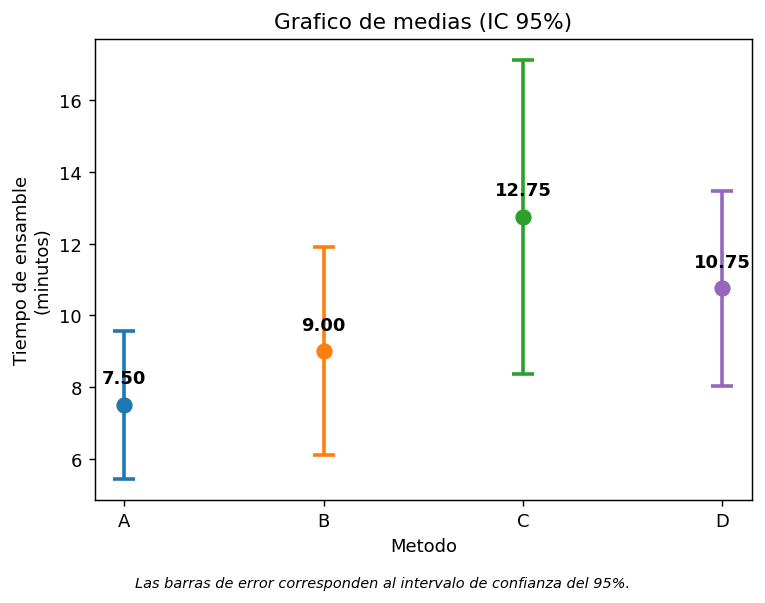


Boxplots por Método


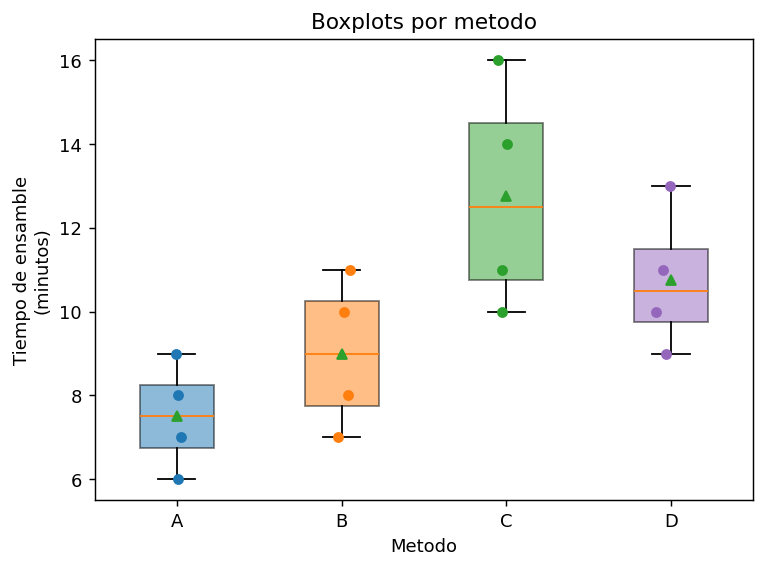


Tabla de Datos del Experimento


,A,B,C,D,Y_.j
Operador,,,,,
1,6,7,10,10,33
2,9,10,16,13,48
3,7,11,11,11,40
4,8,8,14,9,39
Y_i.,30,36,51,43,160



Tabla ANOVA


,SC,gl,CM,F0,valor-p
Metodos,61.500000,3,20.500000,10.250000,0.002900
Bloques,28.500000,3,9.500000,4.750000,0.029800
Error,18.000000,9,2.000000,nan,nan
Total,108.000000,15,nan,nan,nan



Promedios por Método


,Total,Promedio
Metodo,,
A,30,7.500000
B,36,9.000000
C,51,12.750000
D,43,10.750000


In [ ]:
from IPython.display import Image, display, HTML

def style_table(df):
    """Applies basic styling to a DataFrame for HTML display."""
    return df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#ADD8E6'), ('color', 'black'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#F0F8FF')]}, # AliceBlue for even rows
        {'selector': 'tr:hover', 'props': [('background-color', '#FFFFE0')]} # Light yellow on hover
    ]).to_html()

# Display the plots
print('Gráfico de Medias (IC 95%)')
display(Image('grafico_medias.png'))

print('\nBoxplots por Método')
display(Image('boxplots.png'))

# Display the tables with styling
print('\nTabla de Datos del Experimento')
display(HTML(style_table(tabla_datos)))

print('\nTabla ANOVA')
display(HTML(style_table(tabla_anova.round(4))))

print('\nPromedios por Método')
display(HTML(style_table(resumen.round(2))))

## 6. Análisis de Residuos

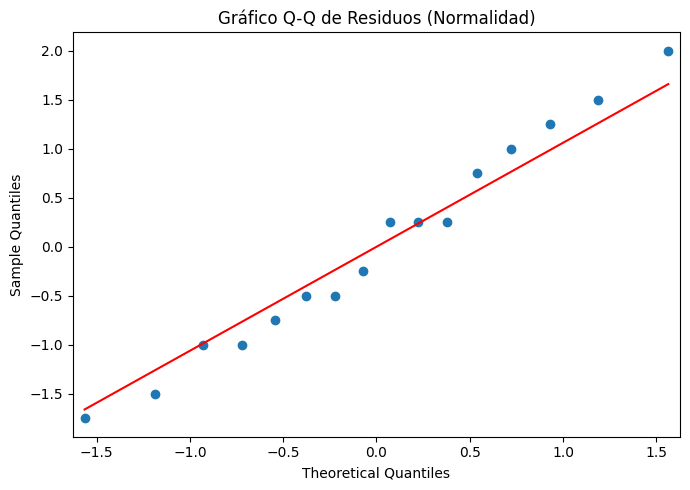

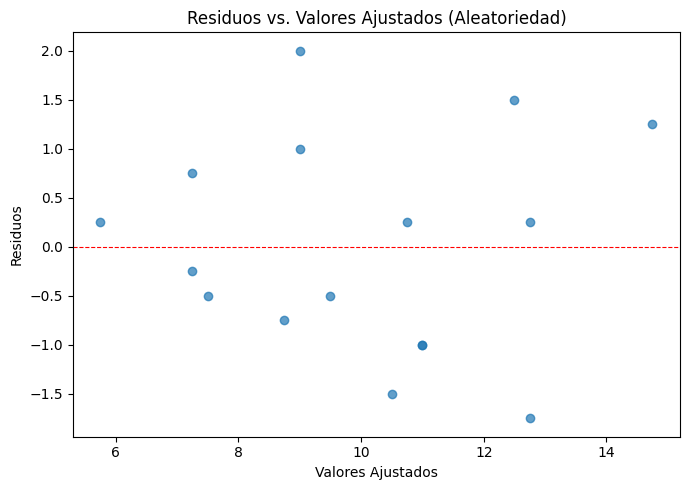

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
from scipy import stats

# Re-crear df_long y ajustar el modelo OLS (si no se ha hecho ya en celdas anteriores)
# Esto es crucial para asegurar que 'df_long' y 'modelo' existen para el análisis de residuos

df_long = Y.reset_index().melt(id_vars='Operador', var_name='Metodo', value_name='Tiempo')
df_long['Operador'] = df_long['Operador'].astype(str)

modelo = ols('Tiempo ~ C(Metodo) + C(Operador)', data=df_long).fit()

# Obtener los residuos del modelo
residuos = modelo.resid

# Gráfico de Normalidad (Q-Q plot de los residuos)
fig_norm, ax_norm = plt.subplots(figsize=(7, 5))
sm.qqplot(residuos, line='s', ax=ax_norm)
ax_norm.set_title('Gráfico Q-Q de Residuos (Normalidad)')
plt.tight_layout()
plt.savefig('qq_plot_residuos.png', dpi=130, bbox_inches='tight')
plt.show()

# Gráfico de Aleatoriedad (Residuos vs. Valores Ajustados)
valores_ajustados = modelo.fittedvalues
fig_rand, ax_rand = plt.subplots(figsize=(7, 5))
ax_rand.scatter(valores_ajustados, residuos, alpha=0.7)
ax_rand.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax_rand.set_xlabel('Valores Ajustados')
ax_rand.set_ylabel('Residuos')
ax_rand.set_title('Residuos vs. Valores Ajustados (Aleatoriedad)')
plt.tight_layout()
plt.savefig('residuos_vs_ajustados.png', dpi=130, bbox_inches='tight')
plt.show()

### Interpretación de los gráficos de residuos:

*   **Gráfico Q-Q de Residuos (Normalidad)**: Si los puntos siguen aproximadamente la línea recta, los residuos se distribuyen normalmente.
*   **Residuos vs. Valores Ajustados (Aleatoriedad)**: Si los puntos se dispersan aleatoriamente alrededor de la línea horizontal de cero sin ningún patrón discernible (forma de "abanico", "embudo", o curvatura), los residuos son aleatorios e independientes.

### Conclusiones

Con un nivel de significancia $\alpha = 0.05$:

*   **Métodos de Ensamble**: El valor-p para los métodos (0.0029) es menor que $\alpha$ (0.05). Esto significa que **se rechaza la hipótesis nula ($H_0$)**, y existe evidencia estadísticamente significativa de que al menos un par de métodos de ensamble presenta un tiempo medio diferente. En otras palabras, no todos los métodos tienen el mismo tiempo de ensamble promedio.

*   **Operadores (Bloques)**: El valor-p para los bloques (0.0298) también es menor que $\alpha$ (0.05). Esto indica que **el bloqueo por operador fue efectivo**, lo que sugiere que existen diferencias significativas en el tiempo de ensamble debido a los operadores.

**Ejercicio 2**

TABLA DE DATOS COMPLETA
Recorrido Recorrido 1 Recorrido 2 Recorrido 3
Vehiculo                                     
1           15.50 (A)   15.60 (B)   16.60 (C)
2           13.00 (B)   13.10 (A)   13.50 (C)
3           11.80 (B)   13.40 (C)   12.20 (A)
4           14.20 (A)   14.80 (C)   15.00 (B)
5           12.40 (B)   14.00 (A)   14.30 (C)
6           15.60 (C)   14.90 (A)   14.70 (B)
7           13.20 (C)   12.00 (B)   12.00 (A)
8           14.90 (C)   14.35 (B)   15.00 (A)
9           12.40 (A)   13.50 (C)   12.30 (B)
Total          123.00      125.65      125.60

Totales por compuesto:
Compuesto
A    123.30
B    121.15
C    129.80
Name: Consumo, dtype: float64

TABLA ANOVA
                SC  gl      CM       F0  valor-p
Compuesto   4.5072   2  2.2536  14.2084   0.0004
Recorrido   0.5106   2  0.2553   1.6095   0.2349
Vehiculo   38.7733   8  4.8467  30.5569   0.0000
Error       2.2206  14  0.1586      NaN      NaN
Total      46.0117  26     NaN      NaN      NaN

CONCLUSION
Compu

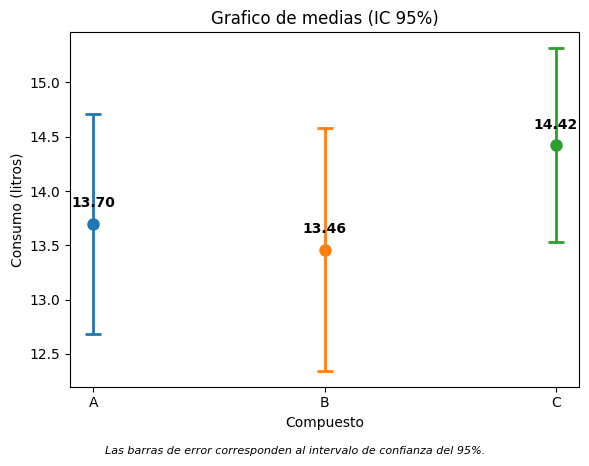

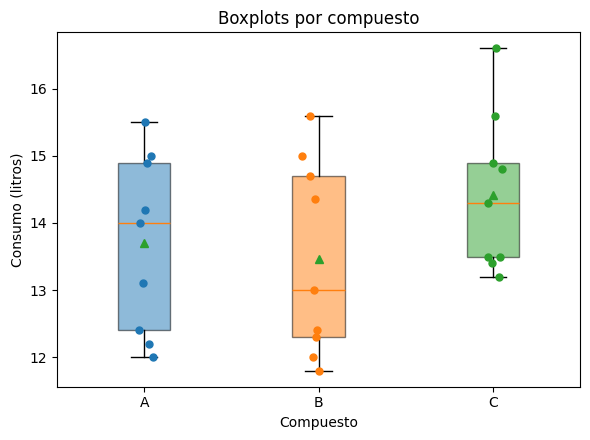

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# =========================================================
# 1. DATOS DEL EXPERIMENTO
#    9 vehiculos x 3 recorridos, cada celda tiene un compuesto
#    (A, B o C) balanceado: cada vehiculo prueba los 3 compuestos
#    (uno por recorrido) y cada recorrido recibe cada compuesto
#    3 veces -> diseno tipo cuadrado latino replicado.
# =========================================================
registros = [
    (1, 'Recorrido 1', 15.5, 'A'), (1, 'Recorrido 2', 15.6, 'B'), (1, 'Recorrido 3', 16.6, 'C'),
    (2, 'Recorrido 1', 13.0, 'B'), (2, 'Recorrido 2', 13.1, 'A'), (2, 'Recorrido 3', 13.5, 'C'),
    (3, 'Recorrido 1', 11.8, 'B'), (3, 'Recorrido 2', 13.4, 'C'), (3, 'Recorrido 3', 12.2, 'A'),
    (4, 'Recorrido 1', 14.2, 'A'), (4, 'Recorrido 2', 14.8, 'C'), (4, 'Recorrido 3', 15.0, 'B'),
    (5, 'Recorrido 1', 12.4, 'B'), (5, 'Recorrido 2', 14.0, 'A'), (5, 'Recorrido 3', 14.3, 'C'),
    (6, 'Recorrido 1', 15.6, 'C'), (6, 'Recorrido 2', 14.9, 'A'), (6, 'Recorrido 3', 14.7, 'B'),
    (7, 'Recorrido 1', 13.2, 'C'), (7, 'Recorrido 2', 12.0, 'B'), (7, 'Recorrido 3', 12.0, 'A'),
    (8, 'Recorrido 1', 14.9, 'C'), (8, 'Recorrido 2', 14.35, 'B'), (8, 'Recorrido 3', 15.0, 'A'),
    (9, 'Recorrido 1', 12.4, 'A'), (9, 'Recorrido 2', 13.5, 'C'), (9, 'Recorrido 3', 12.3, 'B'),
]
df = pd.DataFrame(registros, columns=['Vehiculo', 'Recorrido', 'Consumo', 'Compuesto'])

# --- Tabla de datos completa (igual a la imagen) ---
tabla = df.pivot(index='Vehiculo', columns='Recorrido', values='Consumo')
letras = df.pivot(index='Vehiculo', columns='Recorrido', values='Compuesto')
tabla_mostrar = tabla.copy().astype(object)
for c in tabla.columns:
    tabla_mostrar[c] = [f'{v:.2f} ({l})' for v, l in zip(tabla[c], letras[c])]
tabla_mostrar.loc['Total'] = [f'{tabla[c].sum():.2f}' for c in tabla.columns]

print('=' * 70)
print('TABLA DE DATOS COMPLETA')
print('=' * 70)
print(tabla_mostrar)
print('\nTotales por compuesto:')
print(df.groupby('Compuesto')['Consumo'].sum().round(2))

# =========================================================
# 2. SUMAS DE CUADRADOS Y TABLA ANOVA
#    (Vehiculo, Recorrido y Compuesto estan balanceados entre
#     si, por lo que sus sumas de cuadrados son ortogonales)
# =========================================================
N = len(df)
FC = df['Consumo'].sum()**2 / N
SST = (df['Consumo']**2).sum() - FC

def suma_cuadrados(data, columna):
    g = data.groupby(columna)['Consumo'].agg(['sum', 'count'])
    return (g['sum']**2 / g['count']).sum() - FC

SS_compuesto = suma_cuadrados(df, 'Compuesto')
SS_recorrido = suma_cuadrados(df, 'Recorrido')
SS_vehiculo = suma_cuadrados(df, 'Vehiculo')
SS_error = SST - SS_compuesto - SS_recorrido - SS_vehiculo

gl_compuesto = df['Compuesto'].nunique() - 1
gl_recorrido = df['Recorrido'].nunique() - 1
gl_vehiculo = df['Vehiculo'].nunique() - 1
gl_total = N - 1
gl_error = gl_total - gl_compuesto - gl_recorrido - gl_vehiculo

CM_compuesto = SS_compuesto / gl_compuesto
CM_recorrido = SS_recorrido / gl_recorrido
CM_vehiculo = SS_vehiculo / gl_vehiculo
CM_error = SS_error / gl_error

F_compuesto = CM_compuesto / CM_error
F_recorrido = CM_recorrido / CM_error
F_vehiculo = CM_vehiculo / CM_error

p_compuesto = stats.f.sf(F_compuesto, gl_compuesto, gl_error)
p_recorrido = stats.f.sf(F_recorrido, gl_recorrido, gl_error)
p_vehiculo = stats.f.sf(F_vehiculo, gl_vehiculo, gl_error)

tabla_anova = pd.DataFrame({
    'SC':      [SS_compuesto, SS_recorrido, SS_vehiculo, SS_error, SST],
    'gl':      [gl_compuesto, gl_recorrido, gl_vehiculo, gl_error, gl_total],
    'CM':      [CM_compuesto, CM_recorrido, CM_vehiculo, CM_error, np.nan],
    'F0':      [F_compuesto, F_recorrido, F_vehiculo, np.nan, np.nan],
    'valor-p': [p_compuesto, p_recorrido, p_vehiculo, np.nan, np.nan],
}, index=['Compuesto', 'Recorrido', 'Vehiculo', 'Error', 'Total'])

print('\n' + '=' * 70)
print('TABLA ANOVA')
print('=' * 70)
print(tabla_anova.round(4))

# =========================================================
# 3. CONCLUSION
# =========================================================
alpha = 0.05
print('\n' + '=' * 70)
print('CONCLUSION')
print('=' * 70)

def concluir(nombre, p):
    if p < alpha:
        print(f'{nombre}: valor-p = {p:.4f} < {alpha}  ->  Se rechaza H0. '
              f'Hay diferencia estadisticamente significativa.')
    else:
        print(f'{nombre}: valor-p = {p:.4f} >= {alpha}  ->  No se rechaza H0. '
              f'No hay evidencia suficiente de diferencia.')

concluir('Compuesto', p_compuesto)
concluir('Recorrido', p_recorrido)
concluir('Vehiculo', p_vehiculo)

# =========================================================
# 4. PROMEDIOS POR COMPUESTO
# =========================================================
resumen = df.groupby('Compuesto')['Consumo'].agg(Total='sum', Promedio='mean', n='count')
print('\n' + '=' * 70)
print('PROMEDIOS POR COMPUESTO')
print('=' * 70)
print(resumen.round(3))

# =========================================================
# 5. GRAFICO DE MEDIAS (IC 95%) POR COMPUESTO
# =========================================================
compuestos = sorted(df['Compuesto'].unique())
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

medias = df.groupby('Compuesto')['Consumo'].mean()
desv = df.groupby('Compuesto')['Consumo'].std(ddof=1)
n_c = df.groupby('Compuesto')['Consumo'].count()
t_crit = stats.t.ppf(0.975, df=n_c - 1)
margen = t_crit * desv / np.sqrt(n_c)

fig, ax = plt.subplots(figsize=(6, 4.5))
for i, comp in enumerate(compuestos):
    ax.errorbar(i, medias[comp], yerr=margen[comp], fmt='o', color=colores[i],
                capsize=6, markersize=8, elinewidth=2, capthick=2)
    ax.annotate(f'{medias[comp]:.2f}', (i, medias[comp]), textcoords='offset points',
                xytext=(0, 12), ha='center', fontweight='bold')
ax.set_xticks(range(len(compuestos)))
ax.set_xticklabels(compuestos)
ax.set_xlabel('Compuesto')
ax.set_ylabel('Consumo (litros)')
ax.set_title('Grafico de medias (IC 95%)')
fig.text(0.5, -0.02, 'Las barras de error corresponden al intervalo de confianza del 95%.',
          ha='center', fontsize=8, style='italic')
plt.tight_layout()
plt.savefig('grafico_medias_compuesto.png', dpi=130, bbox_inches='tight')
plt.show()

# =========================================================
# 6. BOXPLOTS POR COMPUESTO
# =========================================================
fig, ax = plt.subplots(figsize=(6, 4.5))
datos_box = [df.loc[df['Compuesto'] == c, 'Consumo'] for c in compuestos]
bp = ax.boxplot(datos_box, tick_labels=compuestos, patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

rng = np.random.default_rng(0)
for i, c in enumerate(compuestos):
    y = df.loc[df['Compuesto'] == c, 'Consumo']
    x_jitter = rng.normal(i + 1, 0.04, size=len(y))
    ax.scatter(x_jitter, y, color=colores[i], zorder=3, s=25)

ax.set_xlabel('Compuesto')
ax.set_ylabel('Consumo (litros)')
ax.set_title('Boxplots por compuesto')
plt.tight_layout()
plt.savefig('boxplots_compuesto.png', dpi=130, bbox_inches='tight')
plt.show()

TABLA CON EL DATO PERDIDO (NaN)
             A     B     C
Vehiculo                  
1         15.5  15.6  16.6
2         13.1  13.0  13.5
3         12.2  11.8  13.4
4         14.2  15.0  14.8
5         14.0  12.4  14.3
6         14.9  14.7  15.6
7         12.0  12.0  13.2
8         15.0   NaN  14.9
9         12.4  12.3  13.5

ESTIMACION DEL DATO PERDIDO
Dato perdido: Vehiculo 8, Compuesto B
B (total del bloque)      = 29.9
T (total del tratamiento) = 106.8
G (gran total)            = 359.90000000000003
Valor estimado X = 14.3500

Tabla con el dato ya estimado:
             A      B     C
Vehiculo                   
1         15.5  15.60  16.6
2         13.1  13.00  13.5
3         12.2  11.80  13.4
4         14.2  15.00  14.8
5         14.0  12.40  14.3
6         14.9  14.70  15.6
7         12.0  12.00  13.2
8         15.0  14.35  14.9
9         12.4  12.30  13.5

TABLA ANOVA (dato perdido estimado)
                       SC  GL      CM       F0  valor-p
Tratamientos (A)   4.5072   2 

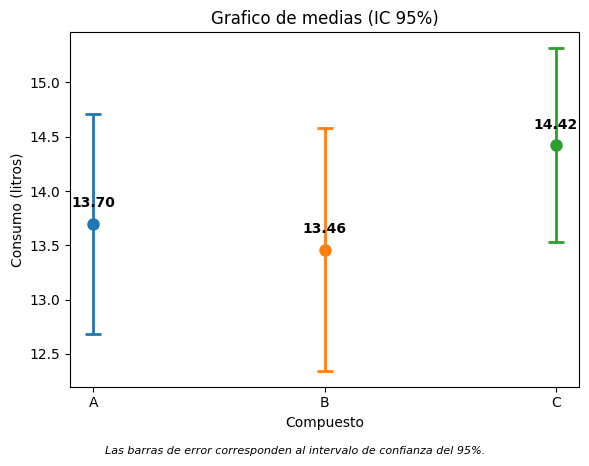

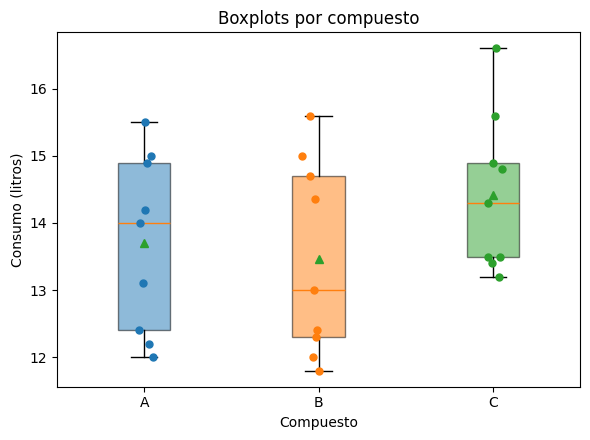

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# =========================================================
# 1. DATOS DEL EXPERIMENTO, CON UN DATO PERDIDO
#    (Vehiculo 8, Compuesto B -> NO se observo su consumo)
#    filas = vehiculos (bloques), columnas = compuestos (tratamientos)
# =========================================================
datos = {
    1: {'A': 15.5, 'B': 15.6, 'C': 16.6},
    2: {'A': 13.1, 'B': 13.0, 'C': 13.5},
    3: {'A': 12.2, 'B': 11.8, 'C': 13.4},
    4: {'A': 14.2, 'B': 15.0, 'C': 14.8},
    5: {'A': 14.0, 'B': 12.4, 'C': 14.3},
    6: {'A': 14.9, 'B': 14.7, 'C': 15.6},
    7: {'A': 12.0, 'B': 12.0, 'C': 13.2},
    8: {'A': 15.0, 'B': np.nan, 'C': 14.9},   # <- dato perdido
    9: {'A': 12.4, 'B': 12.3, 'C': 13.5},
}
Y = pd.DataFrame(datos).T[['A', 'B', 'C']]
Y.index.name = 'Vehiculo'

t = Y.shape[1]   # tratamientos (compuestos) = 3
r = Y.shape[0]   # bloques (vehiculos) = 9

print('=' * 65)
print('TABLA CON EL DATO PERDIDO (NaN)')
print('=' * 65)
print(Y)

# =========================================================
# 2. ESTIMACION DEL DATO PERDIDO (formula de Yates para DBCA)
#    X = (r*B + t*T - G) / [(t-1)(r-1)]
#    B = total del bloque (vehiculo) sin el dato perdido
#    T = total del tratamiento (compuesto) sin el dato perdido
#    G = gran total sin el dato perdido
# =========================================================
fila_i, col_j = np.where(Y.isna())
fila_i, col_j = Y.index[fila_i[0]], Y.columns[col_j[0]]

B = Y.loc[fila_i].sum()
T = Y[col_j].sum()
G = Y.values[~np.isnan(Y.values.astype(float))].sum()

X_hat = (r * B + t * T - G) / ((t - 1) * (r - 1))

print('\n' + '=' * 65)
print('ESTIMACION DEL DATO PERDIDO')
print('=' * 65)
print(f'Dato perdido: Vehiculo {fila_i}, Compuesto {col_j}')
print(f'B (total del bloque)      = {B}')
print(f'T (total del tratamiento) = {T}')
print(f'G (gran total)            = {G}')
print(f'Valor estimado X = {X_hat:.4f}')

Y_completo = Y.copy()
Y_completo.loc[fila_i, col_j] = X_hat

print('\nTabla con el dato ya estimado:')
print(Y_completo.round(2))

# =========================================================
# 3. TABLA ANOVA (grados de libertad corregidos: se pierde 1 gl
#    en el error y 1 en el total, porque el dato no es informacion
#    independiente sino una estimacion)
# =========================================================
N = t * r
FC = Y_completo.values.sum()**2 / N
SST = (Y_completo.values**2).sum() - FC

Y_i_punto = Y_completo.sum(axis=0)          # total por compuesto
SS_trat = (Y_i_punto**2).sum() / r - FC

Y_punto_j = Y_completo.sum(axis=1)          # total por vehiculo
SS_bloques = (Y_punto_j**2).sum() / t - FC

SS_error = SST - SS_trat - SS_bloques

gl_trat = t - 1
gl_bloques = r - 1
gl_error = (t - 1) * (r - 1) - 1            # -1 por el dato estimado
gl_total = N - 1 - 1                        # -1 por el dato estimado

CM_trat = SS_trat / gl_trat
CM_bloques = SS_bloques / gl_bloques
CM_error = SS_error / gl_error

F0_trat = CM_trat / CM_error
F0_bloques = CM_bloques / CM_error

p_trat = stats.f.sf(F0_trat, gl_trat, gl_error)
p_bloques = stats.f.sf(F0_bloques, gl_bloques, gl_error)

tabla_anova = pd.DataFrame({
    'SC':      [SS_trat, SS_bloques, SS_error, SST],
    'GL':      [gl_trat, gl_bloques, gl_error, gl_total],
    'CM':      [CM_trat, CM_bloques, CM_error, np.nan],
    'F0':      [F0_trat, F0_bloques, np.nan, np.nan],
    'valor-p': [p_trat, p_bloques, np.nan, np.nan],
}, index=['Tratamientos (A)', 'Bloques (B)', 'Error', 'Total'])

print('\n' + '=' * 65)
print('TABLA ANOVA (dato perdido estimado)')
print('=' * 65)
print(tabla_anova.round(4))
print(f'\nNota: gl del error = (a-1)(b-1) - 1 = {gl_error}, porque se estimo un dato.')

# =========================================================
# 4. CONCLUSION
# =========================================================
alpha = 0.05
print('\n' + '=' * 65)
print('CONCLUSION')
print('=' * 65)

def concluir(nombre, p):
    if p < alpha:
        print(f'{nombre}: valor-p = {p:.4f} < {alpha}  ->  Se rechaza H0. '
              f'Hay diferencia estadisticamente significativa.')
    else:
        print(f'{nombre}: valor-p = {p:.4f} >= {alpha}  ->  No se rechaza H0.')

concluir('Tratamientos (Compuesto)', p_trat)
concluir('Bloques (Vehiculo)', p_bloques)

# =========================================================
# 5. PROMEDIOS POR COMPUESTO (con el dato ya estimado)
# =========================================================
resumen = pd.DataFrame({'Total': Y_completo.sum(), 'Promedio': Y_completo.mean()})
resumen.index.name = 'Compuesto'
print('\n' + '=' * 65)
print('PROMEDIOS POR COMPUESTO')
print('=' * 65)
print(resumen.round(3))

# =========================================================
# 6. GRAFICO DE MEDIAS (IC 95%)
# =========================================================
compuestos = list(Y_completo.columns)
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

medias = Y_completo.mean()
desv = Y_completo.std(ddof=1)
t_crit = stats.t.ppf(0.975, df=r - 1)
margen = t_crit * desv / np.sqrt(r)

fig, ax = plt.subplots(figsize=(6, 4.5))
for i, c in enumerate(compuestos):
    ax.errorbar(i, medias[c], yerr=margen[c], fmt='o', color=colores[i],
                capsize=6, markersize=8, elinewidth=2, capthick=2)
    ax.annotate(f'{medias[c]:.2f}', (i, medias[c]), textcoords='offset points',
                xytext=(0, 12), ha='center', fontweight='bold')
ax.set_xticks(range(len(compuestos)))
ax.set_xticklabels(compuestos)
ax.set_xlabel('Compuesto')
ax.set_ylabel('Consumo (litros)')
ax.set_title('Grafico de medias (IC 95%)')
fig.text(0.5, -0.02, 'Las barras de error corresponden al intervalo de confianza del 95%.',
          ha='center', fontsize=8, style='italic')
plt.tight_layout()
plt.savefig('grafico_medias_missing.png', dpi=130, bbox_inches='tight')
plt.show()

# =========================================================
# 7. BOXPLOTS POR COMPUESTO
# =========================================================
fig, ax = plt.subplots(figsize=(6, 4.5))
bp = ax.boxplot([Y_completo[c] for c in compuestos], tick_labels=compuestos,
                 patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

rng = np.random.default_rng(0)
for i, c in enumerate(compuestos):
    x_jitter = rng.normal(i + 1, 0.04, size=len(Y_completo[c]))
    ax.scatter(x_jitter, Y_completo[c], color=colores[i], zorder=3, s=25)

ax.set_xlabel('Compuesto')
ax.set_ylabel('Consumo (litros)')
ax.set_title('Boxplots por compuesto')
plt.tight_layout()
plt.savefig('boxplots_missing.png', dpi=130, bbox_inches='tight')
plt.show()